# Time-Series Analysis

In [2]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 11.3 MB/s  0:00:01 eta 0:00:0136m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [statsmodels] 4/5 [statsmodels]


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from statsmodels.graphics.tsaplots import (
    plot_acf,
    plot_pacf
)

from statsmodels.tsa.stattools import (
    adfuller,
    kpss
)

from statsmodels.tsa.seasonal import STL

from statsmodels.stats.diagnostic import (
    acorr_ljungbox
)

pd.set_option('display.max_columns', None)

sns.set_theme(style="whitegrid")

In [4]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables" / "phase5_time_series"

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [5]:
hourly = pd.read_csv(
    PROCESSED_DIR / "air_quality_features.csv",
    parse_dates=['time'],
    index_col='time'
)

In [6]:
daily = pd.read_csv(
    PROCESSED_DIR / "air_quality_daily.csv",
    parse_dates=['time'],
    index_col='time'
)

In [7]:
print("Hourly:", hourly.shape)
print("Daily:", daily.shape)

print(
    "Hourly frequency:",
    pd.infer_freq(hourly.index)
)

print(
    "Daily frequency:",
    pd.infer_freq(daily.index)
)

print(
    "Missing hourly values:",
    hourly['pm25'].isna().sum()
)

print(
    "Missing daily values:",
    daily['pm25_mean'].isna().sum()
)

Hourly: (23352, 43)
Daily: (973, 30)
Hourly frequency: h
Daily frequency: D
Missing hourly values: 0
Missing daily values: 0


In [8]:
#two PM2.5 series
hourly_pm25 = (
    hourly['pm25']
    .astype(float)
    .copy()
)

daily_pm25 = (
    daily['pm25_mean']
    .astype(float)
    .copy()
)

In [9]:
print(hourly_pm25.describe())
print()
print(daily_pm25.describe())

count    23352.000000
mean        35.045422
std         23.252260
min          0.200000
25%         18.800000
50%         29.000000
75%         44.600000
max        170.400000
Name: pm25, dtype: float64

count    973.000000
mean      35.045422
std       19.090764
min        0.583333
25%       20.112500
50%       30.791667
75%       45.683333
max      119.158333
Name: pm25_mean, dtype: float64


In [10]:
#Hourly PM2.5 persistence

hourly_lags = [
    1,
    3,
    6,
    12,
    24,
    48,
    72,
    168
]

In [12]:
#correlation
hourly_lag_correlations = {}

for lag in hourly_lags:

    correlation = hourly_pm25.corr(
        hourly_pm25.shift(lag)
    )

    hourly_lag_correlations[lag] = correlation


hourly_lag_correlations = pd.Series(
    hourly_lag_correlations,
    name='correlation'
).to_frame()

hourly_lag_correlations.index.name = 'lag_hours'

hourly_lag_correlations

,correlation
lag_hours,
1,0.964568
3,0.847723
6,0.666240
12,0.461233
24,0.876913
48,0.801338
72,0.752890
168,0.686989


In [13]:
hourly_lag_correlations['description'] = [
    '1 hour',
    '3 hours',
    '6 hours',
    '12 hours',
    '1 day',
    '2 days',
    '3 days',
    '1 week'
]

hourly_lag_correlations

,correlation,description
lag_hours,,
1,0.964568,1 hour
3,0.847723,3 hours
6,0.666240,6 hours
12,0.461233,12 hours
24,0.876913,1 day
48,0.801338,2 days
72,0.752890,3 days
168,0.686989,1 week


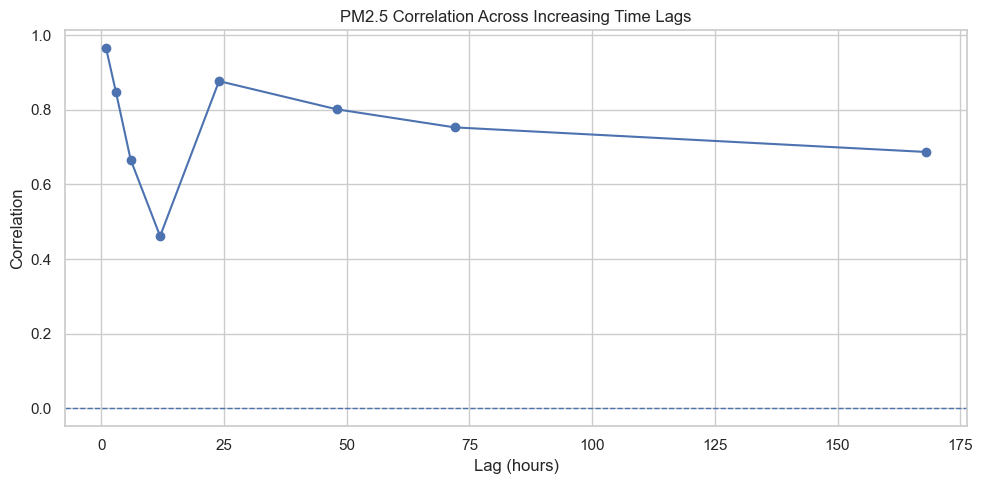

In [14]:
#lag correlation decay
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_lag_correlations.index,
    hourly_lag_correlations['correlation'],
    marker='o'
)

plt.axhline(
    0,
    linestyle='--',
    linewidth=1
)

plt.title(
    'PM2.5 Correlation Across Increasing Time Lags'
)

plt.xlabel('Lag (hours)')
plt.ylabel('Correlation')

plt.tight_layout()
plt.show()